# **2.** Datasets

In the first notebook, we have learnt the basics of data representations, and how data such as text, music and images, is stored as numbers in a computer. Later, we also explored how to extract useful information from these representations.

But, what is the natural next step for teaching a machine how to make decisions? 

Well, we need to have a data to work with! Think of it as examples the computer can look at to learn. We refer to this collection of data as a **dataset**.

Ideally, a dataset should meet the following criteria:

- Contain a **large number** of examples, and we will call each of them a **sample**, **observation** or **instance**;
- Be **representative** of the whole scope of possibilities we could encounter in the task we want to accomplish;
- Be available under a **permissive license** that allows for training machine learning models with non-commercial applications.

There are many available datasets that we can use for different applications, but we will select a relevant one for each type of data (text, music and images) to explore how to work with them.

 > Want to know what else is out there? You could look for available datasets on popular websites such as [`kaggle`](https://www.kaggle.com/datasets)!


## 1: Text dataset: Netflix Movies and TV Shows

To continue our adventure analysing text, we'll take a look at the [Netflix Movies and TV Shows dataset](https://www.kaggle.com/datasets/shivamb/netflix-shows).

For each row of data, this database presents the following information:

* show_id: Unique ID for every Movie / TV Show
* type: Identifier - Movie or TV Show
* title
* director (available for Movies)
* cast: Actors involved 
* country
* date_added: Date it was added on Netflix
* release_year: Actual Release year
* rating
* duration: Total Duration - in minutes or number of seasons
* listed_in: genres or categories
* description: text synopsis


> Can you think of interesting analysis to perform with this information?


For working with it in this notebook, we can simply download it using the `kaggle` package.

In [89]:
!pip install kaggle
# Download the Netflix Movies and TV Shows dataset from Kaggle
!kaggle datasets download -d shivamb/netflix-shows


[notice] A new release of pip is available: 25.3 -> 26.0
[notice] To update, run: python.exe -m pip install --upgrade pip


Dataset URL: https://www.kaggle.com/datasets/shivamb/netflix-shows
License(s): CC0-1.0
netflix-shows.zip: Skipping, found more recently modified local copy (use --force to force download)


Since the dataset is in a zip file, we need to extract its content.

In [90]:
import zipfile
with zipfile.ZipFile("netflix-shows.zip", 'r') as zip_ref:
    zip_ref.extractall("netflix-shows")

The dataset is in the form of a `csv` file, that is _comma separated values_ that indicate data in the form of a table.
A useful library for working with `csv` files is `pandas`, which is usually referred to in code as `pd`.

In [91]:
import pandas as pd

netflix_titles = pd.read_csv("netflix-shows/netflix_titles.csv")

### Exploring the Netflix Dataset

Let's visualise what data we have available.

In [92]:
# Check the structure and columns
print("Number of titles:", netflix_titles.shape[0])

print("\nColumn names:")
print(netflix_titles.columns.tolist())

print("\nFirst few rows:")
netflix_titles.head()

Number of titles: 8807

Column names:
['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']

First few rows:


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


We have a lot to explore! 

As a first approach, we'll only focus on the description and type information.

In [93]:
# keep only the type and description columns
netflix_titles_filtered = netflix_titles[['type', 'description']]

We can check the first row's description with the following code:

In [94]:
netflix_titles_filtered.loc[0, 'description']

'As her father nears the end of his life, filmmaker Kirsten Johnson stages his death in inventive and comical ways to help them both face the inevitable.'

And we can see its type like this:

In [95]:
netflix_titles_filtered.loc[0, 'type']

'Movie'

One of the first things we should check is how many samples we have for TV shows, and how many we have for movies:

Distribution of content types:
type
Movie      6131
TV Show    2676
Name: count, dtype: int64

Percentage distribution:
type
Movie      69.615079
TV Show    30.384921
Name: proportion, dtype: float64


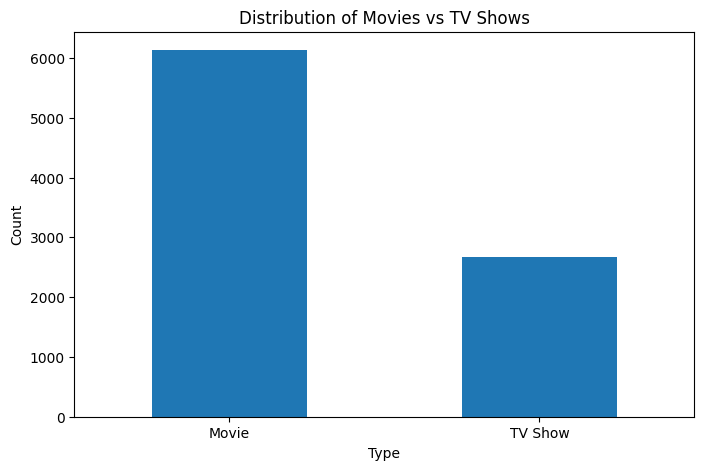

In [96]:
import matplotlib.pyplot as plt

# Check the distribution of Movies vs TV Shows
print("Distribution of content types:")
print(netflix_titles_filtered['type'].value_counts())
print("\nPercentage distribution:")
print(netflix_titles_filtered['type'].value_counts(normalize=True) * 100)

# Visualize the distribution
plt.figure(figsize=(8, 5))
netflix_titles_filtered['type'].value_counts().plot(kind='bar')
plt.title('Distribution of Movies vs TV Shows')
plt.xlabel('Type')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

We have much more Movies than TV Shows in the database! We can say this database is _unbalanced_ in that sense: simply by having more examples, any algorithm we train will have more details about the behaviour of Movie descriptions. This can lead to problems when training an algorithm if not handled properly, so we need to keep it in mind!

Going back to the data: If you were to read the description of one of the samples in the table, could you guess if it's a Movie or a TV Show? Can you think of possible words that would steer your decision one way or another?

Now, let's check what similar information could a machine get from the dataset!

### Text Analysis: Words and Bigrams in Descriptions 📊

Let's analyze the most common words and word-pairs (bigrams) in movies and TV show descriptions!

We have previously learnt how to perform this analysis for a single text. When we had just one text to analyse, our procedure was to simply use a counter to discover the frequency of each word or bigram. 

Now the situation is a bit different, since we have many different texts and two categories. How can we consider the information of many different texts to get an idea of how movies or TV shows descriptions tend to behave? 

First, we should separate the information of movies from the one from TV shows:


In [97]:
# Separate movies and TV shows
movies = netflix_titles_filtered[netflix_titles_filtered['type'] == 'Movie']
tv_shows = netflix_titles_filtered[netflix_titles_filtered['type'] == 'TV Show']

print(f"Movies: {len(movies)}")
print(f"TV Shows: {len(tv_shows)}")

Movies: 6131
TV Shows: 2676


While we could join all descriptions for movies and follow the procedure of the previous notebook, it would be helpful for our future tasks to preserve some sense of structure in the information: we need to be able to trace back how many times each word appeared in each individual text.

For this reason, we are going to use the `CountVectorizer` feature extractor from the `sklearn` library. This is a very useful object that:
1. Creates the vocabulary of all the words in all the descriptions
2. Counts the times each word appears in each description
3. Stores the counts in a table

Note that this approach allows us to track where each count of words came from!

Another advantage of using `CountVectorizer` is that it can automatically filter out common stop words (for example "the", "and" or "is") that don't add information about what the text is about. That is done adding the option `stop_words='english'` to the call.

In [98]:
from sklearn.feature_extraction.text import CountVectorizer

# Create a CountVectorizer for single words
word_vectorizer = CountVectorizer(
    # remove common English stop words e.g., "the", "and", "is", they don't add much information
    stop_words='english',
    # number of top words to consider
    max_features=20
)

# Use CountVectorizer to analyse all movie descriptions
movie_word_counts = word_vectorizer.fit_transform(movies['description'])

The table built by `CountVectorizer` has:
* as many rows as movies we are analysing (6130 in this case).
* one column per each top word to consider (20 in this case). 

The stored information is, then, for each desciption and each top word, how many times did that word appear in that description.

In [99]:
print(movie_word_counts)

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 6142 stored elements and shape (6131, 20)>
  Coords	Values
  (0, 2)	1
  (0, 9)	1
  (0, 6)	1
  (3, 9)	1
  (3, 17)	1
  (4, 17)	1
  (4, 1)	1
  (4, 19)	1
  (5, 13)	1
  (5, 15)	1
  (6, 9)	1
  (6, 18)	1
  (7, 13)	1
  (7, 8)	1
  (8, 2)	1
  (10, 2)	1
  (10, 17)	1
  (10, 12)	1
  (11, 6)	1
  (11, 17)	1
  (11, 12)	1
  (11, 11)	1
  (12, 7)	1
  (13, 9)	1
  (13, 1)	1
  :	:
  (6109, 3)	1
  (6109, 5)	1
  (6110, 13)	2
  (6110, 4)	1
  (6111, 13)	1
  (6111, 10)	1
  (6113, 6)	1
  (6113, 15)	1
  (6113, 12)	1
  (6113, 7)	1
  (6114, 1)	1
  (6114, 13)	2
  (6114, 4)	1
  (6115, 1)	1
  (6115, 19)	1
  (6115, 13)	1
  (6115, 15)	1
  (6116, 1)	1
  (6117, 1)	1
  (6120, 14)	1
  (6122, 2)	1
  (6128, 18)	1
  (6129, 9)	1
  (6129, 13)	1
  (6130, 1)	1


Note that the first value of the tuple indicates the row the description was stored in, and the second value referrs to the token of the word we are counting, and it was assigned when building the vocabulary.

Then we can use this table to count how many times each top word appeared, summing all the information in each column (each word) for all rows (different descriptions).

In [100]:
movie_word_freq = dict(zip(word_vectorizer.get_feature_names_out(), 
                           movie_word_counts.sum(axis=0).A1))
movie_word_freq

{'documentary': np.int64(313),
 'family': np.int64(440),
 'father': np.int64(261),
 'finds': np.int64(234),
 'friends': np.int64(258),
 'girl': np.int64(185),
 'help': np.int64(199),
 'high': np.int64(178),
 'home': np.int64(237),
 'life': np.int64(573),
 'lives': np.int64(176),
 'love': np.int64(335),
 'man': np.int64(452),
 'new': np.int64(478),
 'old': np.int64(233),
 'school': np.int64(199),
 'takes': np.int64(215),
 'woman': np.int64(383),
 'world': np.int64(304),
 'young': np.int64(558)}

We can do the same for the TV shows.

In [101]:
# Use CountVectorizer for TV Shows descriptions
tv_word_counts = word_vectorizer.fit_transform(tv_shows['description'])
# Get word counts for TV Shows
tv_word_freq = dict(zip(word_vectorizer.get_feature_names_out(), 
                        tv_word_counts.sum(axis=0).A1))
tv_word_freq

{'city': np.int64(79),
 'family': np.int64(195),
 'finds': np.int64(79),
 'friends': np.int64(187),
 'group': np.int64(100),
 'help': np.int64(97),
 'high': np.int64(121),
 'home': np.int64(80),
 'life': np.int64(272),
 'lives': np.int64(101),
 'love': np.int64(169),
 'man': np.int64(86),
 'new': np.int64(231),
 'school': np.int64(140),
 'series': np.int64(311),
 'true': np.int64(79),
 'woman': np.int64(103),
 'world': np.int64(266),
 'years': np.int64(84),
 'young': np.int64(171)}

We can visualize this information in a histogram as we did in the previous number:

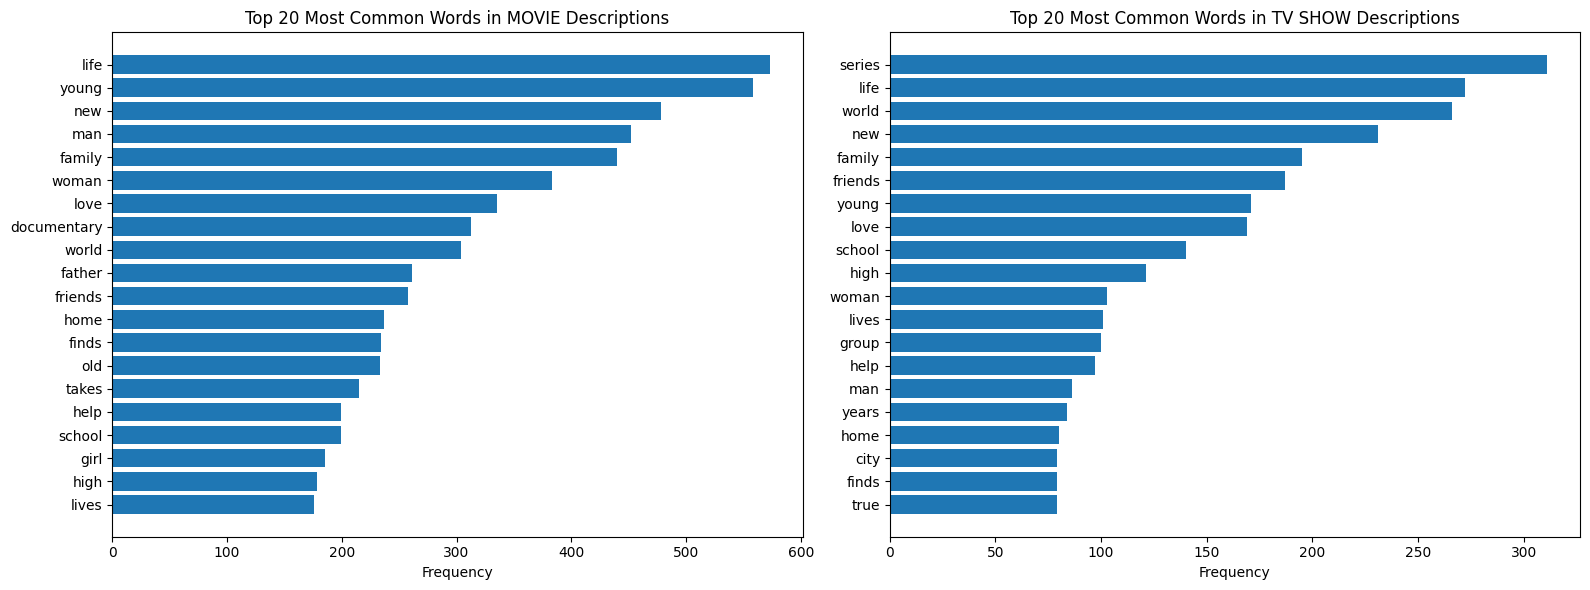

In [102]:
def get_frequency(word_freq_pair):
    word, frequency = word_freq_pair
    return frequency

# rearrange movie top words in order of frequency
top_movie_words = sorted(movie_word_freq.items(), key=get_frequency, reverse=True)
movie_words = [word for word, freq in top_movie_words]
movie_freqs = [freq for word, freq in top_movie_words]
# rearrange TV show top words in order of frequency
top_tv_words = sorted(tv_word_freq.items(), key=get_frequency, reverse=True)
tv_words = [word for word, freq in top_tv_words]
tv_freqs = [freq for word, freq in top_tv_words]

# Visualize
# generate a figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Movie words in the left subplot
ax1.barh(movie_words, movie_freqs)
ax1.set_xlabel('Frequency')
ax1.set_title('Top 20 Most Common Words in MOVIE Descriptions')
ax1.invert_yaxis()

# TV Show words in the right subplot
ax2.barh(tv_words, tv_freqs)
ax2.set_xlabel('Frequency')
ax2.set_title('Top 20 Most Common Words in TV SHOW Descriptions')
ax2.invert_yaxis()

plt.tight_layout()
plt.show()

We can see that the most used word for describint TV Shows is `series`, which makes a lot of sense!

What happens when we take a look at bigrams?

#### Most Common Bigrams (Word Pairs)

For bigrams we can take a very similar procedure. We need to change the settings on `CountVectorizer` so that it count ocurrences of two consecutive words. We do this by adding the `ngram_range=(2, 2)` option in the call.

In [103]:
# Create a CountVectorizer for bigrams (word pairs)
bigram_vectorizer = CountVectorizer(
    stop_words='english',
    ngram_range=(2, 2),  # Bigrams only (pairs of consecutive words)
    max_features=20
)

# Get bigram counts for movies
movie_bigram_counts = bigram_vectorizer.fit_transform(movies['description'])
movie_bigram_freq = dict(zip(bigram_vectorizer.get_feature_names_out(), 
                             movie_bigram_counts.sum(axis=0).A1))

movie_bigram_freq

{'based true': np.int64(40),
 'best friend': np.int64(43),
 'best friends': np.int64(32),
 'documentary follows': np.int64(40),
 'falls love': np.int64(32),
 'high school': np.int64(82),
 'los angeles': np.int64(35),
 'martial arts': np.int64(28),
 'new york': np.int64(79),
 'road trip': np.int64(33),
 'small town': np.int64(48),
 'social media': np.int64(26),
 'stand special': np.int64(45),
 'true story': np.int64(44),
 'war ii': np.int64(29),
 'world war': np.int64(34),
 'year old': np.int64(102),
 'york city': np.int64(30),
 'young man': np.int64(97),
 'young woman': np.int64(86)}

The same for TV shows.

In [104]:
# Get bigram counts for TV shows
tv_bigram_counts = bigram_vectorizer.fit_transform(tv_shows['description'])
tv_bigram_freq = dict(zip(bigram_vectorizer.get_feature_names_out(), 
                          tv_bigram_counts.sum(axis=0).A1))
tv_bigram_freq

{'anthology series': np.int64(13),
 'best friend': np.int64(14),
 'best friends': np.int64(22),
 'documentary series': np.int64(33),
 'high school': np.int64(63),
 'los angeles': np.int64(12),
 'new york': np.int64(19),
 'power rangers': np.int64(15),
 'real life': np.int64(15),
 'reality series': np.int64(29),
 'serial killer': np.int64(12),
 'series based': np.int64(14),
 'series follows': np.int64(23),
 'small town': np.int64(18),
 'true story': np.int64(13),
 'war ii': np.int64(16),
 'world war': np.int64(19),
 'year old': np.int64(43),
 'young man': np.int64(13),
 'young woman': np.int64(25)}

Let's take a look at the histograms!

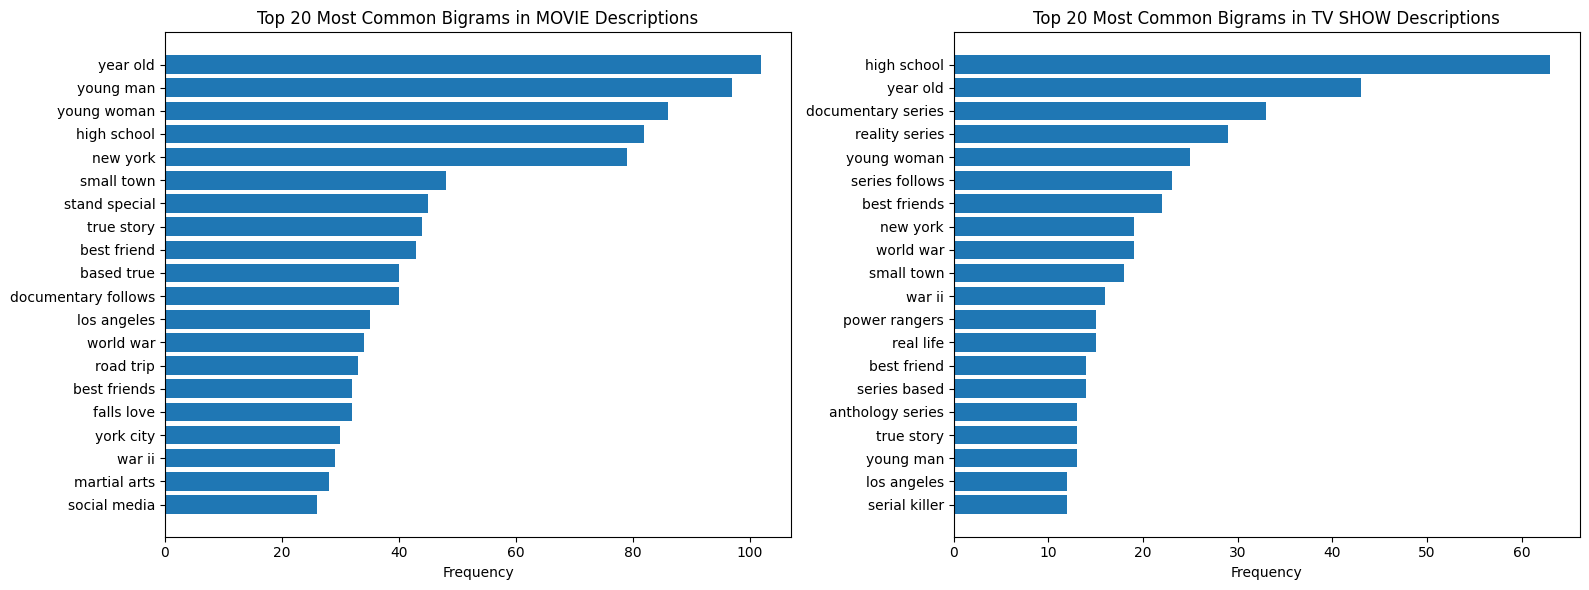

In [105]:
# Sort and get top bigrams
top_movie_bigrams = dict(sorted(movie_bigram_freq.items(), key=get_frequency, reverse=True))
top_tv_bigrams = dict(sorted(tv_bigram_freq.items(), key=get_frequency, reverse=True))

# Visualize
# generate a figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Movie bigrams on the left subplot
ax1.barh(list(top_movie_bigrams.keys()), list(top_movie_bigrams.values()))
ax1.set_xlabel('Frequency')
ax1.set_title('Top 20 Most Common Bigrams in MOVIE Descriptions')
ax1.invert_yaxis()

# TV Show bigrams on the right subplot
ax2.barh(list(top_tv_bigrams.keys()), list(top_tv_bigrams.values()))
ax2.set_xlabel('Frequency')
ax2.set_title('Top 20 Most Common Bigrams in TV SHOW Descriptions')
ax2.invert_yaxis()

plt.tight_layout()
plt.show()

Some bigrams are very common in both cases, such as `year old` and `high school`. We can see that `documentary` appears in both, but when it's for TV shows it appears as `documentary series`.

 What other trends can you spot?

In the next notebook we will use this information to train a model to automatically guess if the description corresponds to a Movie or a TV Show!

## 2: Audio dataset - TinySOL 🧠

Let's say we want to automatically identify instruments from a given audio file.

Watch [this video](https://www.youtube.com/watch?v=tb0gHAzpQPE). *How many instruments can you identify?* What qualities are you listening out for?

Given this task, a good choice of dataset would be TinySOL.

This dataset contains 2913 musical notes recorded from 14 different musical instruments. The instruments are:

1. Tuba 📯
2. French Horn 📯
3. Trombone 🎺
4. Trumpet 🎺
5. Accordion 🎹
6. Double bass 🎻
7. Violin 🎻
8. Viola 🎻
9. Cello 🎻
10. Bassoon 🪈
11. Clarinet 🪈
12. Flute 🪈
13. Oboe 🪈
14. Saxophone 🎷

TinySOL is released under a **CC-BY-4.0 license**. This means that it can be reused **by anyone and for any purpose** (including machine learning), on the condition that the creator is appropriately credited.

For more information on TinySOL and how it was created, [check out this website.](https://zenodo.org/records/3685331)

### MIRData 🎹

In order to work with TinySOL in Python, we're going to use the [`mirdata`](https://github.com/mir-dataset-loaders/mirdata) library. This will allow us to download the dataset and load its audio files **directly in Python**.


Now let's download TinySOL. Note that this dataset is quite large (**1 gigabyte**). Depending on the internet connection, *it may take a while to download*, so please be patient

> If you encounter any HTML errors, please **retry the download** by **rerunning the cell**

In [106]:
import mirdata 

tinysol = mirdata.initialize('tinysol')
tinysol.download()

`mirdata` also allows us to *validate* the dataset, to make sure that we have all the correct files and that nothing is corrupt.

In [107]:
tinysol.validate()

100%|██████████| 2913/2913 [00:28<00:00, 103.61it/s]


({'metadata': {}, 'tracks': {}}, {'metadata': {}, 'tracks': {}})

Great! We've downloaded TinySOL and confirmed that the dataset is valid and complete. Let's take a listen to one of the audio files, selected randomly:

In [108]:
import IPython.display as ipd

track = tinysol.choice_track()
# Identical output to `librosa.load(filename=...)`
y, sr = track.audio
ipd.Audio(y, rate=sr)

> If you run the above code again, you'll get a different file!

What instrument is it?

In [109]:
track.instrument_full

'Violin'

Note that TinySOL was recorded with a *sample rate* of 44,100 Hz. If you're not sure what this means, check out the previous notebook.

### Dataset Exploration 📊

The first thing we should do once we decided to work with a dataset is explore it.

We can start by taking a look at **how many recordings there are** in TinySOL.

In [110]:
len(list(tinysol.load_tracks().values()))

2913

OK, we have **2913 recordings in total** to work with.

Next, let's look at **the number of recordings per instrument**.

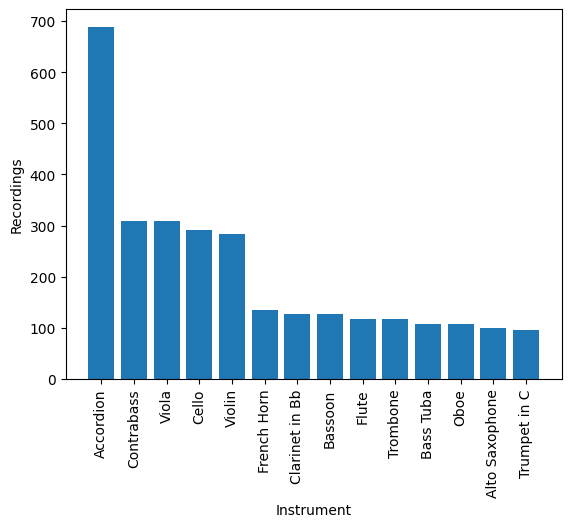

In [111]:
instrs = [rec.instrument_full for rec in tinysol.load_tracks().values()]
res = pd.Series(instrs).value_counts().reset_index(drop=False)

plt.bar(res["index"], res["count"])
plt.xticks(rotation=90)
plt.xlabel("Instrument")
plt.ylabel("Recordings")
plt.show()

Great, from looking at this plot, we can see that **the vast majority of recordings** are on the Accordion. We have over **two times as many Accordion recordings** as we do Contrabass, *the next most common class*. We might call a dataset like this **unbalanced**.

Next, we can look at the number of recordings by each **family** of instruments.

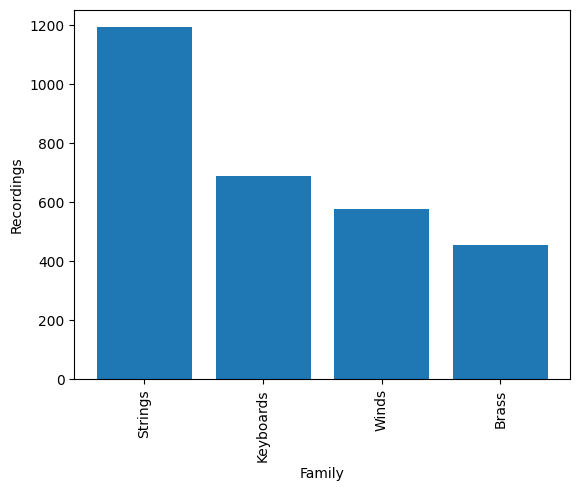

In [112]:
fams = [rec.family for rec in tinysol.load_tracks().values()]

# Note that this code is unchanged from the previous cell
res = pd.Series(fams).value_counts().reset_index(drop=False)
plt.bar(res["index"], res["count"])
plt.xticks(rotation=90)
plt.gca().set(xlabel="Family", ylabel="Recordings")
plt.show()

Great: we can see now that the vast majority of recordings are by instruments from the **string** family (e.g., **Violin**, **Viola**), whereas **brass** recordings (e.g., **Trumpet**, **Trombone**) are much less common in our dataset.

*What other exploratory analyses could we perform for this dataset?*

Think about:
- The duration of recordings
- The qualities of these recordings (e.g., the number of notes they contain)
- Anything else?

### Visualising the Waveform and Spectrogram 🎨

As we saw before, we have two ways of visualising audio information: the waveform, which shows the signals evolution in time, and the spectrogram, that shows the energy for different frequencies of the signal and how they change in time.

Let's look at at the waveform of our file:

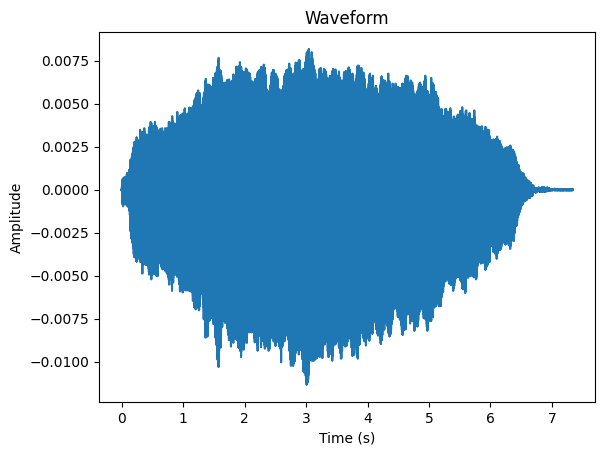

In [113]:
import numpy as np

x_seconds = np.arange(len(y)) / sr
plt.plot(x_seconds, y)
plt.gca().set(xlabel="Time (s)", ylabel="Amplitude")
plt.title("Waveform")
plt.show()

It is clear that the audio deals with only one note! For this particular track: How long does it take for it to reach the maximum amplitude? Does it reach it rapidly or does it increse gradually?

What about the spectrogram?

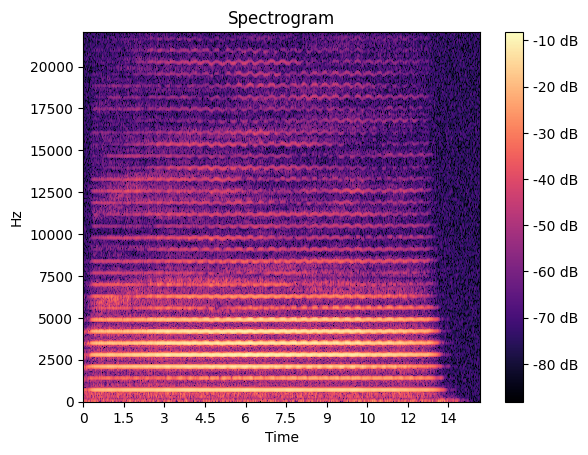

In [114]:
import librosa 

X_stft = np.abs(librosa.stft(y, win_length=512, hop_length=256))
spect = librosa.amplitude_to_db(X_stft)

librosa.display.specshow(spect, sr=sr, x_axis="time", y_axis="linear")
plt.colorbar(format="%+2.0f dB")
plt.title("Spectrogram")
plt.show()

What do you see? Is the energy concentrated in a certain frequency region or is it spread out? Does the distribution of energy across frequencies change over time or does it stay more or less the same?

## Feature Engineering 🔢

In the **Data Analysis** notebook, we saw how to extract some useful statistical information from an audio signal. We call these summary statistics **features**.

Now, we'll try to see how this **features** could help us understand the difference between instruments, finding values for them for all the different **samples** of the dataset.

### Feature Extraction 🏗️

In the **Data Representations** notebook, we explored two types of **temporal features**:
1. **Root Mean Square**: measures the average loudness of a sound over time: a whisper has a low RMS, while a shout has a high RMS
2. **Zero-Crossing Rate**: the fraction of samples in a frame that cross 0, usually higher for noisy or percussive sounds

We also explored two **spectrotemporal features**:

3. **spectral centroid**: the average frequency of every **column** in the spectrogram
4. **spectral bandwidth**: the standard deviation of every **column** in the spectrogram


We're going to define a Python **function** that does the following:

1. Calculates the spectrogram corresponding to an audio file
2. Extracts the **six features** described above from every frame of the spectrogram
3. Gathers these features into a matrix with shape `(N_frames, N_features)`. In other words, every **row** is a frame, and every **column** is a feature.

In [115]:
def extract_features(waveform: np.ndarray, sr: float) -> np.ndarray:
    """
    Extracts features from an audio signal.

    Returns a 2D array, where each row is a frame and each column is a feature
    """
    # Compute the spectrogram
    X_stft = librosa.stft(waveform, win_length=512, hop_length=256)
    spect = np.abs(librosa.amplitude_to_db(np.abs(X_stft)))

    # Extract every feature
    spectral_centroids = librosa.feature.spectral_centroid(S=spect,)
    spectral_bandwidth = librosa.feature.spectral_bandwidth(S=spect,)
    rmse = librosa.feature.rms(S=spect,)
    zero_crossing_rate = librosa.feature.zero_crossing_rate(waveform, frame_length=512, hop_length=256)

    # Stack the features to the shape (N_frames, N_features)
    return np.vstack([
        spectral_centroids,
        spectral_bandwidth,
        rmse,
        zero_crossing_rate,
    ]).T


features = extract_features(y, sr)


Let's check the shape of the feature matrix:

In [116]:
print(features.shape)

(1264, 4)


Great! We can see the number of frames in order file as the first number in the tuple above. For every frame, we've extracted 4 **spectral features**.


#### Frames or Recordings? 🖼

While we could train our model on data extracted from every **frame**, there might be some problems with this:

- Given that each frame lasts a very short amount of time (around 0.01 second!), we might expect successive frames to contain **very similar information**;
- Some frames might not contain audio: for example, if the musician stopped playing **before the recording ended**. These frames could confuse a model.

Because of these reasons, we can instead **average** every feature for a single recording. Recall the equation for the mean of the values in a vector $x$:

$$
\text{mean}(x) = \frac{1}{n} \sum_{i=1}^{n} x_i
$$

To calculate this, we can simply use `numpy`:

In [117]:
features_vector = np.mean(features, axis=0)
print(features_vector.shape)

(4,)


> **Good to know:** notice how we set the `axis=0` parameter above. This means that we **averaged over** the first axis in the matrix (i.e., frames). Compare the shape of `extracted` and `extracted_vector` to see what we mean.
>
> ***What would happen if we set `axis=1`? What shape would we get?***

We now have a **feature vector**: a one-dimensional vector with shape `(N_features,)`. Let's print this out:

In [118]:
print(features_vector.round(3))

[6.009650e+03 3.082676e+03 1.325000e+00 1.350000e-01]


### Extract the features for our whole Database.

For each of the sample audios of the database we need to:

1. Load the audio file from TinySOL
2. Extract the six spectral features from every frame to create a matrix with shape `(N_frames, N_features)`
3. Average every feature over each frame to create a vector of shape `(N_features,)`

We can do that in a function, let's call it `get_averaged_features`

In [119]:
def get_averaged_features(track: tuple) -> np.ndarray:
    """
    Extract average features for a single recording.
    """
    # Extract the features for every frame: shape (N_frames, N_features)
    features = extract_features(track.audio[0], track.audio[1])
    # Average the features over all frames to create a vector: shape (N_features,)
    averaged_features = np.mean(features, axis=0)
    return averaged_features

But, how should we organise the storage of this information once we compute it?

We can stack this vector for every recording to create a matrix with shape `(N_recordings, N_features)`

Run the cell below to extract features from all the recordings in `tinysol`. Note that this may take a while, *so please be patient!*

In [120]:
# Load up all the recordings from tinysol
all_recordings = tinysol.load_tracks()
print(f"Number of recordings: {len(all_recordings)}")


Number of recordings: 2913


In [121]:
from joblib import Parallel, delayed

# Initialise an empty list to store all the feature vectors
all_features = []

# We would normally run the following code:

# for track in filtered_recordings.values():
#     all_features.append(get_averaged_features(track))

# The problem is that it is too slow! We're going to speed it up, but don't worry about the details,
# just know that this allows us to run several pieces of code at the same time (in parallel)

with Parallel(n_jobs=-1, verbose=5) as parallel:
    all_features = parallel(delayed(get_averaged_features)(track) for track in all_recordings.values())

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:   10.4s
[Parallel(n_jobs=-1)]: Done  56 tasks      | elapsed:   12.8s
[Parallel(n_jobs=-1)]: Done 146 tasks      | elapsed:   16.8s
[Parallel(n_jobs=-1)]: Done 272 tasks      | elapsed:   24.9s
[Parallel(n_jobs=-1)]: Done 434 tasks      | elapsed:   34.1s
[Parallel(n_jobs=-1)]: Done 632 tasks      | elapsed:   46.3s
[Parallel(n_jobs=-1)]: Done 866 tasks      | elapsed:  1.0min
[Parallel(n_jobs=-1)]: Done 1136 tasks      | elapsed:  1.3min
[Parallel(n_jobs=-1)]: Done 1442 tasks      | elapsed:  1.6min
[Parallel(n_jobs=-1)]: Done 1784 tasks      | elapsed:  2.0min
[Parallel(n_jobs=-1)]: Done 2162 tasks      | elapsed:  2.4min
[Parallel(n_jobs=-1)]: Done 2576 tasks      | elapsed:  2.8min
[Parallel(n_jobs=-1)]: Done 2913 out of 2913 | elapsed:  3.1min finished


In [122]:
# Stack all of the vectors into a matrix with shape (N_recordings, N_features)
feature_matrix = np.array(all_features)

Great! We can confirm that our pipeline worked correctly by looking at the *shape of the feature matrix*:

In [123]:
print(feature_matrix.shape)

(2913, 4)


This shows we have 2913 recordings, the same number as in TinySOL. For each of these recordings, we have 4 features.

### Visualising Features 📃

Let's start taking a closer look at some of our features.

For now, we'll just visualise the spectral centroid and zero-crossing rate of each recording using **histograms**. These plots show the distribution of values by binning data into discrete groups.

We'll use the `seaborn` library to create these plots.

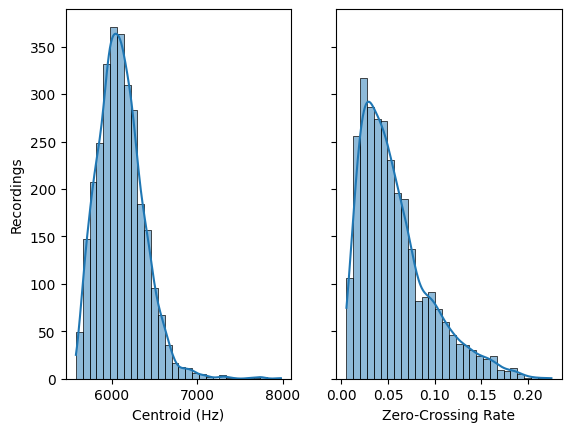

In [142]:
import seaborn as sns

fig, ax = plt.subplots(nrows=1, ncols=2, sharex=False, sharey=True)

sns.histplot(feature_matrix[:, 0], kde='True', ax=ax[0], bins=30)
sns.histplot(feature_matrix[:, 3], kde='True', ax=ax[1], bins=30)

ax[0].set(xlabel="Centroid (Hz)", ylabel="Recordings")
ax[1].set(xlabel="Zero-Crossing Rate", ylabel="")

plt.show()

Now, this is for all the recordings group together. What would happen if we were to get one histogram per instrument family?

In [143]:
feature_names = ['Spectral Centroid', 'Spectral Bandwidth',
                 'RMS', 'Zero-Crossing Rate']
df_features = pd.DataFrame(feature_matrix, columns=feature_names)
# Get the family labels for coloring
families = [rec.family for rec in all_recordings.values()]
df_features['Family'] = families

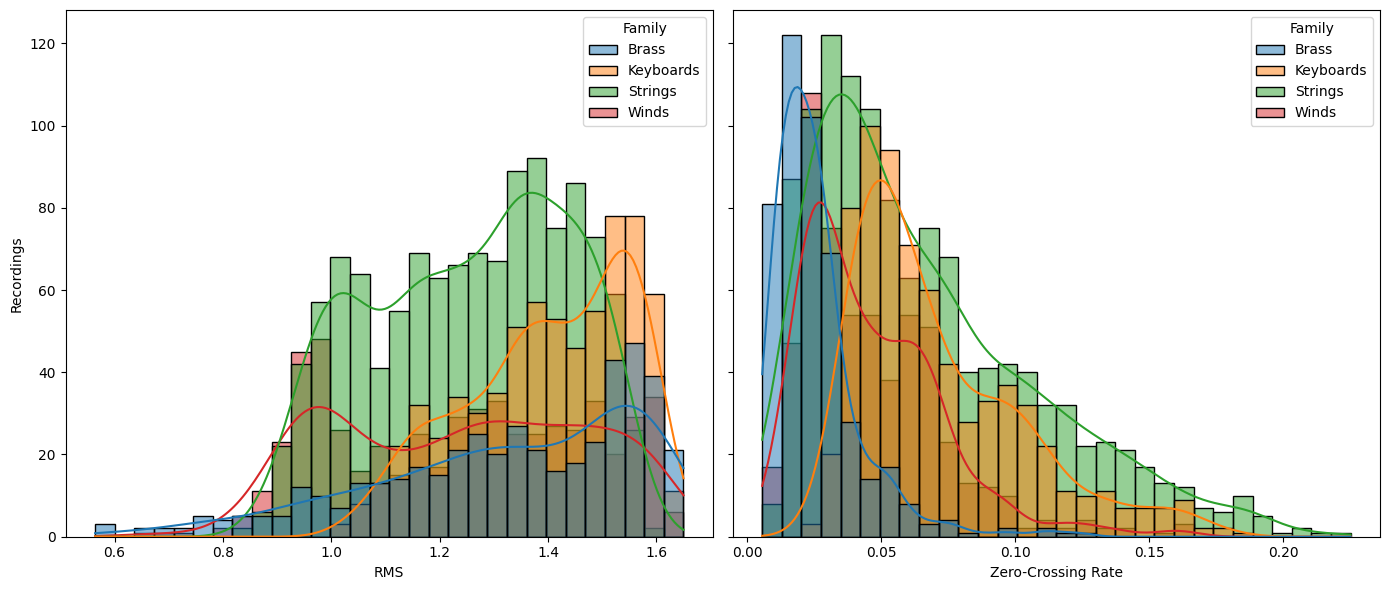

In [146]:
fig, ax = plt.subplots(nrows=1, ncols=2, sharex=False, sharey=True, figsize=(14, 6))

sns.histplot(data=df_features, x='RMS', hue='Family', kde='True', ax=ax[0], bins=30, multiple='layer', alpha=0.5)
sns.histplot(data=df_features, x='Zero-Crossing Rate', hue='Family', kde='True', ax=ax[1], bins=30, multiple='layer', alpha=0.5)

ax[0].set(xlabel="RMS", ylabel="Recordings")
ax[1].set(xlabel="Zero-Crossing Rate", ylabel="")

plt.tight_layout()
plt.show()

We can see different behaviour for different families! This gives us a glue that this features could be useful for analysing a recording and automatically indicate which family it belongs to. What about the other two features?

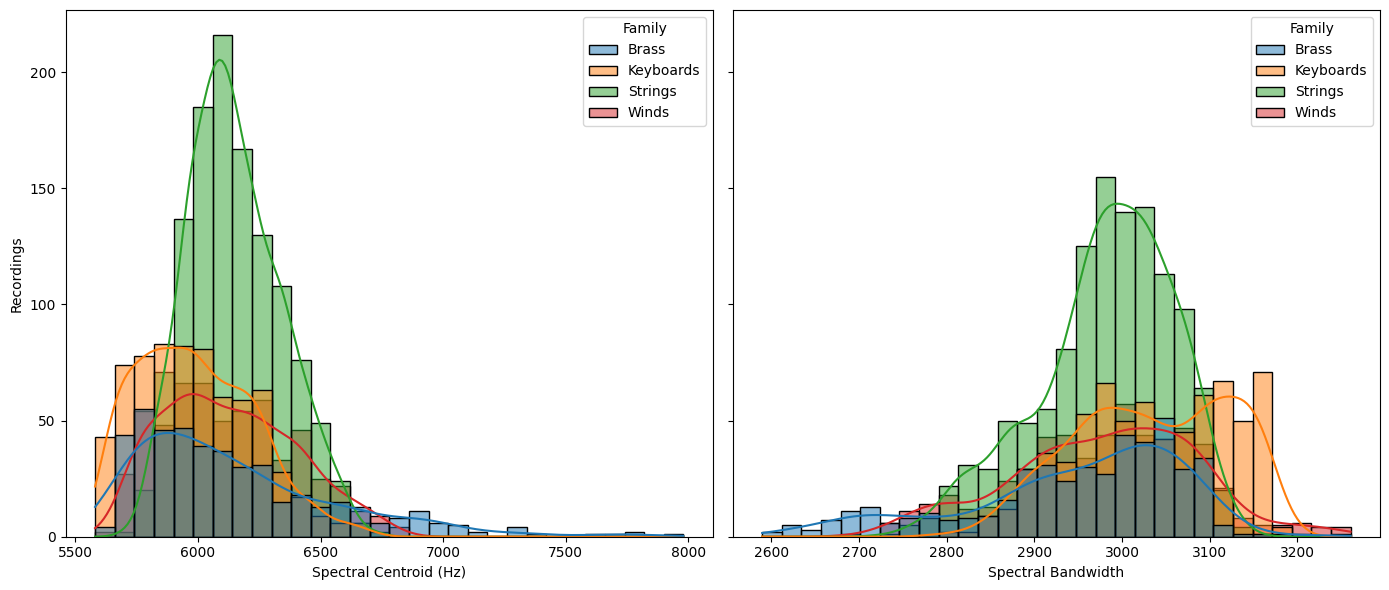

In [147]:
fig, ax = plt.subplots(nrows=1, ncols=2, sharex=False, sharey=True, figsize=(14, 6))

sns.histplot(data=df_features, x='Spectral Centroid', hue='Family', kde='True', ax=ax[0], bins=30, multiple='layer', alpha=0.5)
sns.histplot(data=df_features, x='Spectral Bandwidth', hue='Family', kde='True', ax=ax[1], bins=30, multiple='layer', alpha=0.5)

ax[0].set(xlabel="Spectral Centroid (Hz)", ylabel="Recordings")
ax[1].set(xlabel="Spectral Bandwidth", ylabel="")

plt.tight_layout()
plt.show()

Looking at all the graphs, can you see any feature better than the others at separating between families?

We will use all of this information for training a classifier in the next notebook.

## 3. Images : CIFAR-10

Now it's the time for images!

We will analyse the images from the [CIFAR-10 dataset](https://www.kaggle.com/competitions/cifar-10/data), consisting on 32x32 color images, belonging to one of these classes:
* airplane 
* automobile 
* bird 
* cat 
* deer 
* dog 
* frog 
* horse 
* ship 
* truck

First, let's download the dataset from `kaggle`:

In [125]:
# Download the CIFAR-10 dataset from Kaggle
!kaggle datasets download -d oxcdcd/cifar10

Dataset URL: https://www.kaggle.com/datasets/oxcdcd/cifar10
License(s): copyright-authors
cifar10.zip: Skipping, found more recently modified local copy (use --force to force download)


Let's extract it. We'll have a `labels.txt` file that indicates the name of the classes, and  `test` and `train` folders with images for the different classes. Don't worry about this distinction now, we will get to it in the next notebook!

In [126]:
with zipfile.ZipFile("cifar10.zip", 'r') as zip_ref:
    zip_ref.extractall("cifar10")

Let's look at some images we have for automobiles:

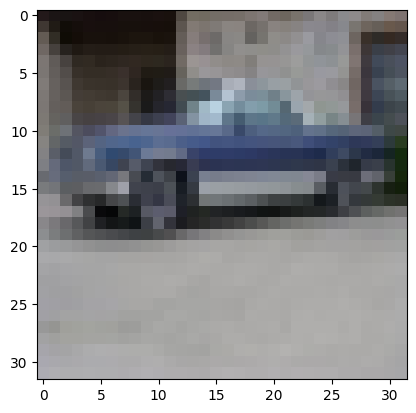

In [150]:
import skimage
import os

# change the label as you wish to explore the other classes!
label = 'automobile'
images_base_path = f'cifar10/cifar10/train/{label}/'
images_paths = os.listdir(images_base_path)

# change the index here to show a different image
index = 0
image_to_show = images_paths[index]
image = skimage.io.imread(os.path.join(images_base_path, image_to_show))
plt.imshow(image)

> Change the label and the index values in the code above to explore the dataset!

This dataset has been used heavily for classification tasks, that is, developing a system that given a new image that belongs to one of the defined classes, can confidently identify which class it belongs to.

For the sake of simplicity, we will now work with only two classes: `automobiles` and `airplanes`.

We can first analyse the colour histogram of the image we checked before.

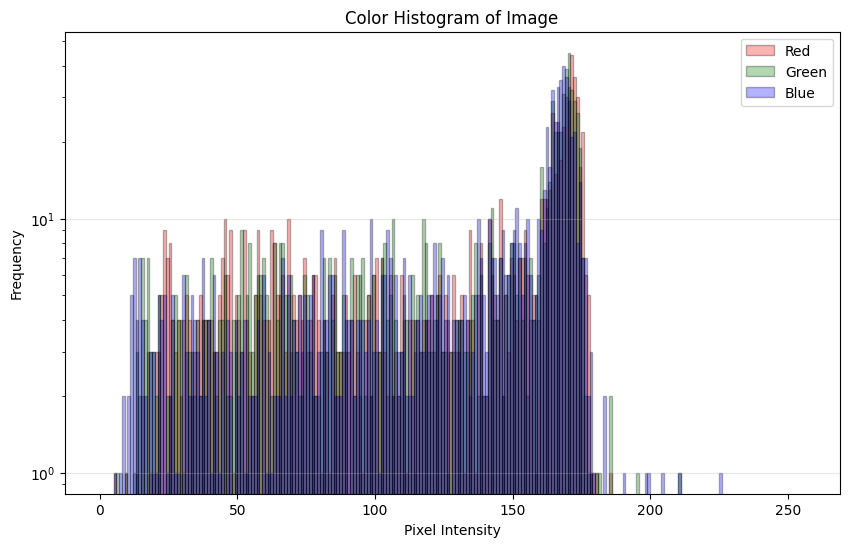

In [153]:
plt.figure(figsize=(10, 6))

# Extract each color channel
red = image[:, :, 0].flatten()
green = image[:, :, 1].flatten()
blue = image[:, :, 2].flatten()

# Plot histograms for each channel
plt.hist(red, bins=256, range=(0, 256), alpha=0.3, label='Red', color='red', edgecolor='black')
plt.hist(green, bins=256, range=(0, 256), alpha=0.3, label='Green', color='green', edgecolor='black')
plt.hist(blue, bins=256, range=(0, 256), alpha=0.3, label='Blue', color='blue', edgecolor='black')

plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.title('Color Histogram of Image')
plt.legend()
plt.yscale('log')
plt.grid(axis='y', alpha=0.3)
plt.show()

Can we extend the code to average the histogram of the whole class?

In [157]:
def plot_histogram_for_class(label):
    images_base_path = f'cifar10/cifar10/train/{label}/'
    images_paths = os.listdir(images_base_path)

    plt.figure(figsize=(10, 6))

    # Initialize lists to accumulate all pixel values
    all_red = []
    all_green = []
    all_blue = []

    for image_name in images_paths[:5]:
        image = skimage.io.imread(os.path.join(images_base_path, image_name))
        # Extract each color channel
        all_red.extend(image[:, :, 0].flatten())
        all_green.extend(image[:, :, 1].flatten())
        all_blue.extend(image[:, :, 2].flatten())

    # Plot histograms for each channel
    plt.hist(all_red, bins=256, range=(0, 256), alpha=0.3, label='Red', color='red', edgecolor='black', density=True)
    plt.hist(all_green, bins=256, range=(0, 256), alpha=0.3, label='Green', color='green', edgecolor='black', density=True)
    plt.hist(all_blue, bins=256, range=(0, 256), alpha=0.3, label='Blue', color='blue', edgecolor='black', density=True)

    plt.xlabel('Pixel Intensity')
    plt.ylabel('Frequency')
    plt.title('Color Histogram of Image')
    plt.legend()
    plt.yscale('log')
    plt.grid(axis='y', alpha=0.3)
    plt.show()

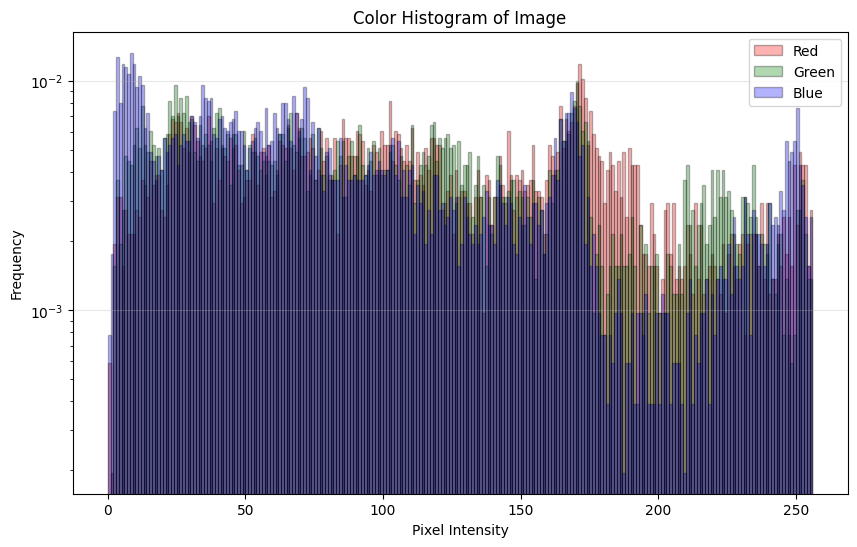

In [159]:
plot_histogram_for_class('automobile')


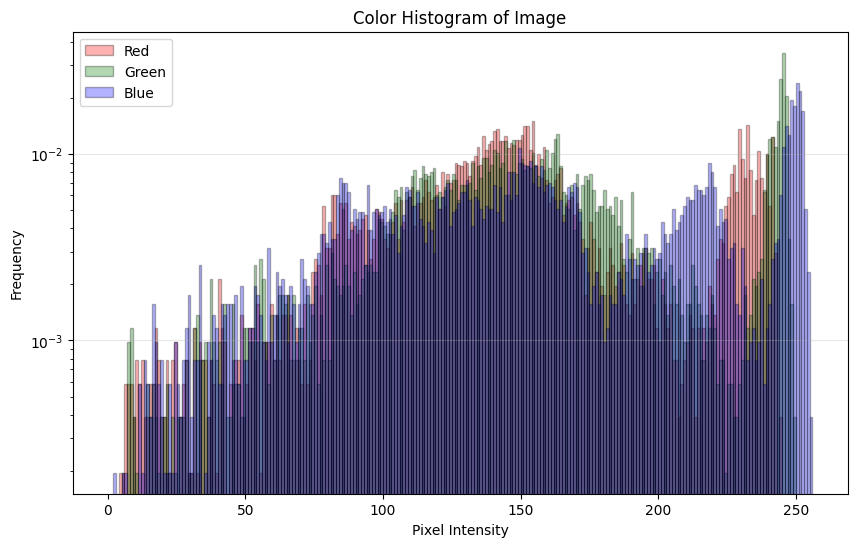

In [160]:
plot_histogram_for_class('airplane')


We can see that the colour histograms for the two classes are completely diferent! If we have a new image of an airplane or an automobile and we compute its colour histogram, we could check which one of these two is more similar, and therefore conclude what is in the image.

# Conclusion: Datasets
